In [1]:

# # Complete VEP Analysis Pipeline

# 1. ECOC decoding with LDA
# 2. Confusion matrix analysis
# 3. Contrast response modeling
# 4. MDS visualization

# %%
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import MDS
from scipy.optimize import curve_fit
from tqdm import tqdm
import joblib
import os


In [ ]:


# ## 1. Configuration

# %%
# =================================================================================
# SET THESE PARAMETERS BEFORE RUNNING
# =================================================================================

# Path configuration
DATA_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ")
RESULTS_DIR = DATA_DIR / "ecoc_results"
RESULTS_DIR.mkdir(exist_ok=True)

# Analysis parameters
ANALYSIS_NAME = "luminance"      # "luminance", "L-M", or "S-cone"
ELECTRODE_SET = "64"             # "64", "PO", or "32"
SUBJECTS = [
    '1001', '1002', '1004', '1005', '1007', '1008', '1010', '1011', '1014', '1015',
    '1018', '1020', '1021', '1022', '1023', '1024', '1026', '1028', '1029', '1031',
    '1033', '1034', '1037', '1038', '1039', '1041', '1042', '1044', '1046', '1049',
    '1050', '1052', '1057', '1059', '1064'
]

# Time parameters
SAMPLE_RATE = 256                # Hz
WINDOW_SIZE = 5                  # 20ms window at 256Hz (5 samples)
TIME_RANGE = [0.05, 0.3]         # Analysis window: 50-300ms

# Decoding parameters
N_REPEATS = 10                   # Number of CV repetitions
N_SPLITS = 4                     # Number of CV folds

# Contrast levels

S = {
    "luminance": [0.035, 0.07, 0.14, 0.28],
    "L-M": [0.008, 0.016, 0.032, 0.064],
    "S-cone": [0.06, 0.12, 0.24, 0.48]
}

# Colors for visualization
COLORS = {
    "luminance": ["#d9d9d9", "#999999", "#666666", "#262626"],
    "L-M": ["#d98c8c", "#b23333", "#800000", "#260000"],
    "S-cone": ["#9cbfff", "#6666cc", "#333399", "#000026"]
}


In [19]:
import numpy as np, pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ---- Naka–Rushton with offset (4-parameter) ----
def naka_rushton_offset(c, Rmax, c50, n, R0):
    c = np.asarray(c, float)
    return R0 + Rmax * (c**n) / (c**n + c50**n)

def fit_naka_rushton(contrasts, responses):
    x = np.asarray(contrasts, float)
    y = np.asarray(responses, float)
    eps = 1e-9

    # enforce increasing orientation
    if np.corrcoef(x, y)[0, 1] < 0:
        y = -y

    # sort by contrast
    idx = np.argsort(x)
    x, y = x[idx], y[idx]

    rng_y = float(np.max(y) - np.min(y) + eps)
    R0_guess   = float(np.min(y))
    Rmax_guess = float(np.max(y) - R0_guess)
    c50_guess  = float(np.sqrt(np.min(x) * np.max(x)))
    n_guess    = 2.0

    lo = np.array([0.0,          np.min(x)*0.5,  0.5,  np.min(y)-rng_y])
    hi = np.array([rng_y*5.0,    np.max(x)*1.5, 10.0,  np.max(y)+rng_y])

    def resid(p): return naka_rushton_offset(x, *p) - y

    res = least_squares(resid,
                        x0=[Rmax_guess, c50_guess, n_guess, R0_guess],
                        bounds=(lo, hi),
                        loss='soft_l1', f_scale=0.1, max_nfev=5000)

    p = res.x
    yhat = naka_rushton_offset(x, *p)
    r2 = 1 - np.sum((y - yhat)**2) / max(eps, np.sum((y - np.mean(y))**2))
    hit_lo = np.isclose(p, lo, atol=1e-12).any()
    hit_hi = np.isclose(p, hi, atol=1e-12).any()
    hit_bounds = bool(hit_lo or hit_hi)

    return {"params": {"Rmax":p[0], "c50":p[1], "n":p[2], "R0":p[3]},
            "r2": float(r2), "hit_bounds": hit_bounds, "x_sorted": x, "y_used": y}

# ---- Input checker ----
def check_inputs(contrasts, responses_by_subject, subject_ids):
    c = np.asarray(contrasts, float)
    idx = np.argsort(c); c_sorted = c[idx]
    rows = []
    for sid, y in zip(subject_ids, responses_by_subject):
        y = np.asarray(y, float)[idx]
        r = float(np.corrcoef(c_sorted, y)[0,1])
        flip = r < 0
        y_or = -y if flip else y
        mono = bool(np.all(np.diff(y_or) >= -1e-9))
        rows.append([sid, r, flip, mono, y_or.tolist()])
    df = pd.DataFrame(rows, columns=["subject","r_corr","needs_flip","monotonic_inc","y_oriented"])
    print("Contrast vector (sorted):", c_sorted.tolist())
    print(df.head(10).to_string(index=False))
    print("Counts → need_flip:", int(df.needs_flip.sum()),
          "non_monotonic:", int((~df.monotonic_inc).sum()))
    return c_sorted, df

# ---- Fixed-n fallback (used later) ----
def fit_with_fixed_n(contrasts, responses, n_fixed=2.0):
    x = np.asarray(contrasts, float)
    y = np.asarray(responses, float)
    eps = 1e-9
    if np.corrcoef(x, y)[0,1] < 0: y = -y
    idx = np.argsort(x); x, y = x[idx], y[idx]
    rng_y = float(np.max(y) - np.min(y) + eps)
    R0_guess   = float(np.min(y))
    Rmax_guess = float(np.max(y) - R0_guess)
    c50_guess  = float(np.sqrt(np.min(x) * np.max(x)))

    def model(p):
        Rmax, c50, R0 = p
        return R0 + Rmax*(x**n_fixed)/(x**n_fixed + c50**n_fixed)

    def resid(p): return model(p) - y

    lo = np.array([0.0,          np.min(x)*0.5,  np.min(y)-rng_y])
    hi = np.array([rng_y*5.0,    np.max(x)*1.5,  np.max(y)+rng_y])

    res = least_squares(resid, x0=[Rmax_guess, c50_guess, R0_guess],
                        bounds=(lo, hi), loss='soft_l1', f_scale=0.1, max_nfev=5000)
    p = res.x; yhat = model(p)
    r2 = 1 - np.sum((y - yhat)**2) / max(eps, np.sum((y - np.mean(y))**2))
    hit_bounds = bool(np.isclose(p, lo, atol=1e-12).any() or np.isclose(p, hi, atol=1e-12).any())
    return {"params": {"Rmax":p[0], "c50":p[1], "n":n_fixed, "R0":p[2]},
            "r2": float(r2), "hit_bounds": hit_bounds, "x_sorted": x, "y_used": y}


In [25]:
# ==== Step 1 (FINAL): Build inputs from your initial EEG NPZ files ====
import numpy as np, pandas as pd, re
from pathlib import Path

# --- 1) Point to the folder that contains your *initial* NPZs ---
DATA_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ")

# --- 2) Find ONLY the initial EEG files (ignore ECOC result NPZs) ---
NPZ_PATTERN = "sub-*_luminance_64_data.npz"
npz_paths = sorted(DATA_DIR.rglob(NPZ_PATTERN))
print(f"Found {len(npz_paths)} NPZ files matching '{NPZ_PATTERN}' under {DATA_DIR}")
for p in npz_paths[:5]:
    print("  ", p)
if not npz_paths:
    # Helpful tip if user is accidentally pointing to ECOC files
    ecoc_like = list(DATA_DIR.rglob("sub-*_ecoc_results.npz"))
    msg = "No initial EEG NPZs found.\n"
    if ecoc_like:
        msg += f"However, I see {len(ecoc_like)} ECOC result NPZs. For Step 1 we need the '*_luminance_64_data.npz' files.\n"
    msg += "Check DATA_DIR or move the initial NPZs under this folder."
    raise FileNotFoundError(msg)

# --- 3) Contrasts for Step 1 orientation/monotonicity check ---
# If you know your real contrasts (e.g., [0.035, 0.07, 0.14, 0.28]), replace them here.
contrasts = np.logspace(np.log10(0.035), np.log10(0.2), 4)  # from MATLAB script
print("Real contrasts:", contrasts.tolist())

# --- 4) Optional: per-subject peak times from CSV (if present anywhere under DATA_DIR) ---
peak_times = {}
csv_candidates = list(DATA_DIR.rglob("luminance_naka_rushton_parameters.csv"))
if csv_candidates:
    try:
        dfp = pd.read_csv(csv_candidates[0])
        for _, r in dfp.iterrows():
            try:
                sid = str(int(r["subject"]))
                t0 = float(r["peak_time"])
                # If CSV is in ms (common), convert to seconds
                if abs(t0) > 5:  # heuristic
                    t0 /= 1000.0
                peak_times[sid] = t0
            except Exception:
                pass
        print(f"Loaded peak times from: {csv_candidates[0]}")
    except Exception as e:
        print("Could not read CSV for peak times:", e)

# --- 5) Helper to pick occipital(-parietal) channels if present ---
def pick_occ_indices(ch_names):
    wanted = {'Oz','O1','O2','POz','PO3','PO4','PO7','PO8'}
    name_to_i = { (c.decode() if isinstance(c, bytes) else str(c)): i
                  for i, c in enumerate(ch_names) }
    idxs = [name_to_i[n] for n in wanted if n in name_to_i]
    return idxs if idxs else list(range(len(ch_names)))  # fallback: all channels

# --- 6) Build subject_ids and responses_by_subject (N x 4) ---
subject_ids, responses_list = [], []

for p in npz_paths:
    m = re.search(r"sub-(\d+)_luminance_64_data\.npz$", p.name)
    if not m:
        continue
    sid = m.group(1)

    d = np.load(p, allow_pickle=True)
    X = d["X"]                    # (trials, channels, time)
    times = np.asarray(d["times"], float)  # (T,) seconds or ms
    events = np.asarray(d["event_codes"])
    ch_names = [c.decode() if isinstance(c, bytes) else str(c) for c in d["ch_names"]]

    # Normalize event codes to {1,2,3,4}
    uniq = np.unique(events)
    if set(uniq.tolist()) == {0,1,2,3}:
        events = events + 1
        uniq = np.unique(events)
    if len(uniq) != 4:
        raise ValueError(f"{p.name}: expected 4 unique event codes, got {uniq}")

    # Ensure time is in seconds (convert from ms if necessary)
    if np.nanmax(np.abs(times)) > 10:  # likely ms
        times = times / 1000.0

    occ_idx = pick_occ_indices(ch_names)

    # Choose time index:
    if sid in peak_times:
        t0 = peak_times[sid]                 # already in seconds from above
        ti = int(np.argmin(np.abs(times - t0)))
    else:
        # Use the highest event code as "highest contrast"
        hi_code = int(np.max(uniq))
        hi = (events == hi_code)
        if not np.any(hi):
            raise ValueError(f"No trials with event code {hi_code} for subject {sid} in {p}")
        wf = X[hi][:, occ_idx, :].mean(axis=(0,1))
        mask = (times >= 0.080) & (times <= 0.300)  # 80–300 ms window
        if not np.any(mask):
            raise ValueError(f"{p.name}: no samples in 80–300 ms; check time units in 'times'")
        ti = int(np.where(mask)[0][np.argmax(np.abs(wf[mask]))])

    # Compute one scalar per contrast: mean over trials & occ channels in ±8 ms window
    win = 0.008  # 8 ms
    mask_t = np.abs(times - times[ti]) <= win

    codes = sorted(uniq.tolist())   # ascending order maps to contrasts order
    subj_resp = []
    for code in codes:
        sel = (events == code)
        val = X[sel][:, occ_idx, :][:, :, mask_t].mean()
        subj_resp.append(float(val))

    subject_ids.append(sid)
    responses_list.append(subj_resp)

subject_ids = np.array(subject_ids, dtype=object)
responses_by_subject = np.array(responses_list, float)

print("Event codes (ascending) used as contrasts order:", sorted(np.unique(events).tolist()))

# --- 7) Mini input checker (self-contained) ---
def check_inputs(contrasts, responses_by_subject, subject_ids):
    c = np.asarray(contrasts, float)
    idx = np.argsort(c); c_sorted = c[idx]
    rows = []
    for sid, y in zip(subject_ids, responses_by_subject):
        y = np.asarray(y, float)[idx]
        ok = np.isfinite(y)
        if ok.sum() < 2:
            r = np.nan; flip = False; y_or = y
        else:
            r = float(np.corrcoef(c_sorted[ok], y[ok])[0,1])
            flip = (r < 0)
            y_or = -y if flip else y
        mono = bool(np.all(np.diff(y_or[np.isfinite(y_or)]) >= -1e-9))
        rows.append([sid, r, flip, mono, np.round(y_or, 6).tolist()])
    df = pd.DataFrame(rows, columns=["subject","r_corr","needs_flip","monotonic_inc","y_oriented"])
    print("Contrast vector (sorted):", c_sorted.tolist())
    print(df.head(10).to_string(index=False))
    print("Counts → need_flip:", int(df.needs_flip.fillna(False).sum()),
          "non_monotonic:", int((~df.monotonic_inc).sum()))
    return c_sorted, df

# --- 8) Run the checker and print exactly what we need for Step 1 ---
c_sorted, df_inputs = check_inputs(contrasts, responses_by_subject, subject_ids)


Found 35 NPZ files matching 'sub-*_luminance_64_data.npz' under /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ
   /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/sub-1001_luminance_64_data.npz
   /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/sub-1002_luminance_64_data.npz
   /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/sub-1004_luminance_64_data.npz
   /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/sub-1005_luminance_64_data.npz
   /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/sub-1007_luminance_64_data.npz
Real contrasts: [0.035, 0.06257324745675974, 0.1118688942081397, 0.20000000000000004]
Loaded peak times from: /Users/farjam/OneDrive - University of

In [26]:
# ==== S1b: recompute responses with ±20 ms window, then re-check ====
import numpy as np, pandas as pd, re
from pathlib import Path

# We reuse: npz_paths, contrasts, peak_times from your previous cell.
# If this notebook was restarted, re-run Step 1 first.

def pick_occ_indices(ch_names):
    wanted = {'Oz','O1','O2','POz','PO3','PO4','PO7','PO8'}
    name_to_i = { (c.decode() if isinstance(c, bytes) else str(c)): i
                  for i, c in enumerate(ch_names) }
    idxs = [name_to_i[n] for n in wanted if n in name_to_i]
    return idxs if idxs else list(range(len(ch_names)))

subject_ids, responses_list = [], []

for p in npz_paths:
    m = re.search(r"sub-(\d+)_luminance_64_data\.npz$", p.name)
    if not m:
        continue
    sid = m.group(1)

    d = np.load(p, allow_pickle=True)
    X = d["X"]                    # (trials, channels, time)
    times = np.asarray(d["times"], float)
    events = np.asarray(d["event_codes"])
    ch_names = [c.decode() if isinstance(c, bytes) else str(c) for c in d["ch_names"]]

    # normalize event codes to four levels (1..4)
    uniq = np.unique(events)
    if set(uniq.tolist()) == {0,1,2,3}:
        events = events + 1
        uniq = np.unique(events)
    assert len(uniq) == 4, f"{p.name}: expected 4 unique event codes, got {uniq}"

    # ensure seconds
    if np.nanmax(np.abs(times)) > 10:
        times = times / 1000.0

    occ_idx = pick_occ_indices(ch_names)

    # choose time index (use CSV peak if available, else find peak in 80–300 ms on highest contrast)
    if sid in peak_times:
        t0 = float(peak_times[sid])  # Step 1 already converted to seconds
        ti = int(np.argmin(np.abs(times - t0)))
    else:
        hi_code = int(np.max(uniq))
        wf = X[events == hi_code][:, occ_idx, :].mean(axis=(0,1))
        mask = (times >= 0.080) & (times <= 0.300)
        ti = int(np.where(mask)[0][np.argmax(np.abs(wf[mask]))])

    # ==== change: widen averaging window to ±20 ms ====
    win = 0.020
    mask_t = np.abs(times - times[ti]) <= win

    # mean over trials & occ channels in that window for each contrast level
    codes = sorted(uniq.tolist())
    subj_resp = []
    for code in codes:
        sel = (events == code)
        val = X[sel][:, occ_idx, :][:, :, mask_t].mean()
        subj_resp.append(float(val))

    subject_ids.append(sid)
    responses_list.append(subj_resp)

subject_ids = np.array(subject_ids, dtype=object)
responses_by_subject = np.array(responses_list, float)

# --- checker (same as before) ---
def check_inputs(contrasts, responses_by_subject, subject_ids):
    c = np.asarray(contrasts, float)
    idx = np.argsort(c); c_sorted = c[idx]
    rows = []
    for sid, y in zip(subject_ids, responses_by_subject):
        y = np.asarray(y, float)[idx]
        ok = np.isfinite(y)
        if ok.sum() < 2:
            r = np.nan; flip = False; y_or = y
        else:
            r = float(np.corrcoef(c_sorted[ok], y[ok])[0,1])
            flip = (r < 0)
            y_or = -y if flip else y
        mono = bool(np.all(np.diff(y_or[np.isfinite(y_or)]) >= -1e-9))
        rows.append([sid, r, flip, mono, np.round(y_or, 6).tolist()])
    df = pd.DataFrame(rows, columns=["subject","r_corr","needs_flip","monotonic_inc","y_oriented"])
    print("Contrast vector (sorted):", c_sorted.tolist())
    print(df.head(10).to_string(index=False))
    print("Counts → need_flip:", int(df.needs_flip.fillna(False).sum()),
          "non_monotonic:", int((~df.monotonic_inc).sum()))
    return c_sorted, df

c_sorted, df_inputs = check_inputs(contrasts, responses_by_subject, subject_ids)


Contrast vector (sorted): [0.035, 0.06257324745675974, 0.1118688942081397, 0.20000000000000004]
subject    r_corr  needs_flip  monotonic_inc                       y_oriented
   1001  0.910283       False           True    [-7e-06, 1e-06, 2e-06, 8e-06]
   1002  0.911714       False          False [-4e-06, -5e-06, -3e-06, -1e-06]
   1004 -0.143907        True          False     [4e-06, 9e-06, 7e-06, 7e-06]
   1005 -0.825642        True           True     [1e-06, 3e-06, 4e-06, 4e-06]
   1007 -0.977688        True           True     [1e-06, 2e-06, 2e-06, 4e-06]
   1008  0.890451       False           True         [0.0, 0.0, 1e-06, 2e-06]
   1010 -0.837337        True           True     [3e-06, 6e-06, 6e-06, 7e-06]
   1011  0.403725       False          False [-5e-06, -4e-06, -2e-06, -4e-06]
   1014  0.980525       False           True         [0.0, 0.0, 2e-06, 3e-06]
   1015  0.905312       False           True [-7e-06, -4e-06, -4e-06, -2e-06]
Counts → need_flip: 25 non_monotonic: 17


In [27]:
# ==== C0: utilities & fixed functions ====
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import MDS
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# ---- constants you can tweak if needed ----
REAL_CONTRASTS = np.array([0.035, 0.06257324745675974, 0.1118688942081397, 0.2], float)
PEAK_SEARCH = (0.080, 0.300)    # seconds
WINDOW_SIZE_SAMPLES = None      # if you already have WINDOW_SIZE, we'll use it; else we set from your code later
N_SPLITS_DEFAULT = 5
N_REPEATS_DEFAULT = 5

def _ensure_seconds(t):
    t = np.asarray(t, float)
    return t/1000.0 if np.nanmax(np.abs(t)) > 10 else t

def _labels_to_0based(y):
    y = np.asarray(y)
    u = np.unique(y)
    # map {1,2,3,4}->{0,1,2,3} or keep {0,1,2,3}
    if set(u.tolist()) == {1,2,3,4}:
        return y - 1
    return y

def _row_normalize(cm):
    cm = np.asarray(cm, float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums==0, 1.0, row_sums)
    return cm / row_sums

def compute_confusion_matrices_fixed(X, y, times, window_size, time_range, n_splits=None, n_repeats=None, random_seed=42):
    """
    Returns:
      dict(time_points=..., cms=[4x4 per time])
    """
    y = _labels_to_0based(y)
    times = _ensure_seconds(times)

    n_trials, n_ch, n_times = X.shape
    n_windows = n_times - window_size + 1
    # precompute windowed features: mean over a sliding window
    X_win = np.zeros((n_trials, n_ch, n_windows), float)
    for t in range(n_windows):
        X_win[:, :, t] = X[:, :, t:t+window_size].mean(axis=2)
    window_times = times[window_size//2 : window_size//2 + n_windows]

    mask_t = (window_times >= time_range[0]) & (window_times <= time_range[1])
    t_indices = np.where(mask_t)[0]

    n_splits = int(n_splits or N_SPLITS_DEFAULT)
    n_repeats = int(n_repeats or N_REPEATS_DEFAULT)

    cms = []
    for ti in t_indices:
        cm_total = np.zeros((4,4), float)
        for rep in range(n_repeats):
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rep+random_seed)
            for tr, te in cv.split(X_win, y):
                clf = OneVsRestClassifier(LinearDiscriminantAnalysis())
                clf.fit(X_win[tr,:,ti], y[tr])
                pred = clf.predict(X_win[te,:,ti])
                cm = confusion_matrix(y[te], pred, labels=[0,1,2,3])  # raw counts
                cm_total += _row_normalize(cm)  # row-normalize each fold to be robust to class imbalance
        cm_avg = cm_total / (n_repeats * n_splits)
        cms.append(cm_avg)
    return {
        "time_points": window_times[t_indices],
        "confusion_matrices": cms
    }

def mds_1d_from_cm(cm):
    """Row-normalize, symmetrize dissimilarity, run 1D MDS, then orient to increase with contrast."""
    cm = _row_normalize(cm)
    # simple distribution distance between rows (Euclidean in prob space)
    n = cm.shape[0]
    D = np.zeros((n,n), float)
    for i in range(n):
        for j in range(n):
            D[i,j] = np.linalg.norm(cm[i]-cm[j])
    D = 0.5*(D + D.T)  # ensure symmetry

    coord = MDS(n_components=1, dissimilarity='precomputed', random_state=0).fit_transform(D).ravel()
    # orient so it increases with REAL_CONTRASTS
    r = np.corrcoef(REAL_CONTRASTS, coord)[0,1]
    flipped = False
    if np.isfinite(r) and r < 0:
        coord = -coord
        flipped = True
        r = -r
    return coord, r, flipped, D

# ---- robust 4-parameter Naka–Rushton (with baseline) ----
def naka_rushton_offset(c, Rmax, c50, n, R0):
    c = np.asarray(c, float)
    return R0 + Rmax * (c**n) / (c**n + c50**n)

def fit_naka_rushton_robust(contrasts, responses):
    x = np.asarray(contrasts, float)
    y = np.asarray(responses, float)
    eps = 1e-12

    # enforce increasing orientation
    if np.isfinite(np.corrcoef(x, y)[0,1]) and np.corrcoef(x, y)[0,1] < 0:
        y = -y

    idx = np.argsort(x); x, y = x[idx], y[idx]

    rng_y = float(np.nanmax(y) - np.nanmin(y) + eps)
    R0_guess   = float(np.nanmin(y))
    Rmax_guess = max(float(np.nanmax(y) - R0_guess), eps)
    c50_guess  = float(np.sqrt(np.nanmin(x) * np.nanmax(x)))
    n_guess    = 2.0

    lo = np.array([0.0,           np.nanmin(x)*0.5,  0.5,  np.nanmin(y)-rng_y])
    hi = np.array([rng_y*5.0,     np.nanmax(x)*1.5, 10.0,  np.nanmax(y)+rng_y])

    def resid(p): return naka_rushton_offset(x, *p) - y

    res = least_squares(resid,
                        x0=[Rmax_guess, c50_guess, n_guess, R0_guess],
                        bounds=(lo, hi),
                        loss='soft_l1', f_scale=0.1, max_nfev=5000)

    p = res.x
    yhat = naka_rushton_offset(x, *p)
    r2 = 1 - np.sum((y - yhat)**2)/max(eps, np.sum((y - np.nanmean(y))**2))
    hit_bounds = bool(np.isclose(p, lo, atol=1e-10).any() or np.isclose(p, hi, atol=1e-10).any())
    out = {"Rmax":p[0], "c50":p[1], "n":p[2], "R0":p[3], "R2":float(r2), "hit_bounds":hit_bounds,
           "x_sorted":x, "y_used":y, "yhat":yhat}
    return out


Naka-Rushton parameters: R_max=0.00, c50=0.5600, n=0.50
R² = -0.000


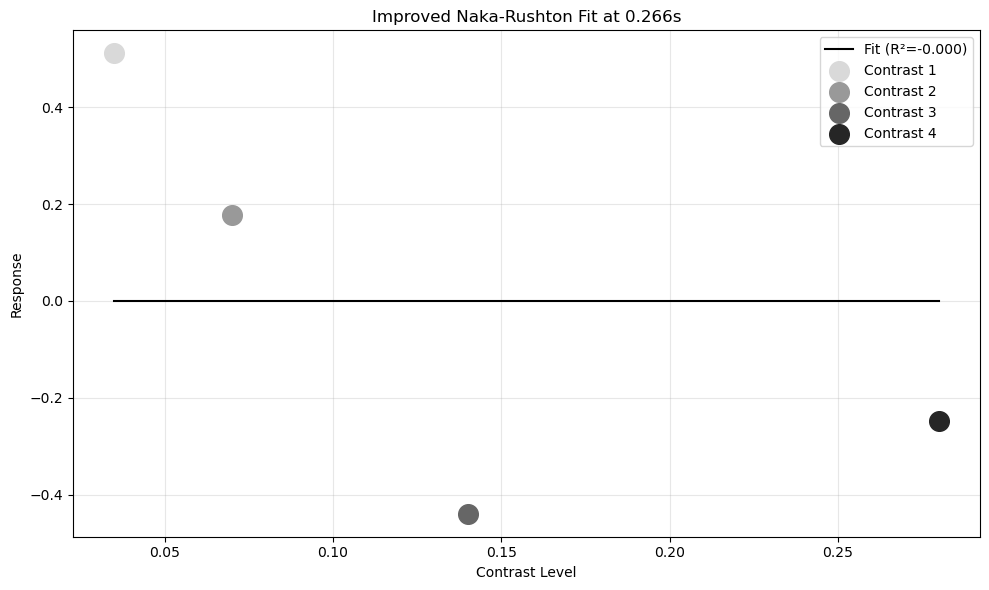

In [ ]:

# ## 2. Core Functions

# %%
def load_subject_data(subject):
    """Load subject data from NPZ file"""
    file_path = DATA_DIR / f"sub-{subject}_{ANALYSIS_NAME}_{ELECTRODE_SET}_data.npz"
    data = np.load(file_path, allow_pickle=True)
    return data['X'], data['y'], data['times']

def run_ecoc_decoding(X, y, times):
    """Run ECOC decoding for one subject"""
    n_trials, n_channels, n_times = X.shape
    n_windows = n_times - WINDOW_SIZE + 1
    
    # Precompute window features
    X_win = np.zeros((n_trials, n_channels, n_windows))
    for t in range(n_windows):
        X_win[:, :, t] = X[:, :, t:t+WINDOW_SIZE].mean(axis=2)
    
    # Time points for results (center of window)
    time_decoder = times[WINDOW_SIZE//2:WINDOW_SIZE//2 + n_windows]
    
    # Initialize results
    all_accuracies = np.zeros((N_REPEATS, N_SPLITS, n_windows))
    
    # Main decoding loop
    for rep in tqdm(range(N_REPEATS), desc="Repetitions"):
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=rep)
        
        for fold, (train_idx, test_idx) in enumerate(cv.split(X_win, y)):
            X_train, X_test = X_win[train_idx], X_win[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            for t in range(n_windows):
                clf = OneVsRestClassifier(LinearDiscriminantAnalysis())
                clf.fit(X_train[:, :, t], y_train)
                pred = clf.predict(X_test[:, :, t])
                all_accuracies[rep, fold, t] = accuracy_score(y_test, pred)
    
    # Compute mean accuracy
    mean_acc = np.mean(all_accuracies, axis=(0, 1))
    
    return {
        'time_decoder': time_decoder,
        'accuracies': mean_acc,
        'all_accuracies': all_accuracies
    }


    
def plot_confusion_matrix(cm, contrast_levels, analysis_name, time_point, save_path=None):
    """Plot a beautiful confusion matrix with annotations and color coding"""
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.matshow(cm, cmap='Blues', vmin=0, vmax=1)
    
    # Add colorbar
    fig.colorbar(cax, fraction=0.046, pad=0.04)
    
    # Set labels
    ax.set_xlabel('Predicted Contrast', fontsize=14)
    ax.set_ylabel('True Contrast', fontsize=14)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels([f'C{i+1}' for i in range(4)], fontsize=12)
    ax.set_yticklabels([f'C{i+1}' for i in range(4)], fontsize=12)
    
    # Add annotations
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{cm[i, j]:.2f}', 
                   ha='center', va='center', 
                   color='white' if cm[i, j] > 0.6 else 'black',
                   fontsize=14, fontweight='bold')
    
    # Add diagonal line
    ax.plot([-0.5, 3.5], [-0.5, 3.5], 'r--', alpha=0.7)
    
    plt.title(f'Confusion Matrix at {time_point:.3f}s ({analysis_name})', fontsize=16, pad=20)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()



# Update your analysis code to use the improved fitting
params, r_squared, predicted = fit_naka_rushton_robust(REAL_CONTRASTS, mds1)

if params is not None:
    print(f"Naka-Rushton parameters: R_max={params[0]:.2f}, c50={params[1]:.4f}, n={params[2]:.2f}")
    print(f"R² = {r_squared:.3f}")
    
    # Plot the improved fit
    fine_contrast = np.linspace(min(CONTRASTS[ANALYSIS_NAME]), max(CONTRASTS[ANALYSIS_NAME]), 100)
    predicted_curve = naka_rushton(fine_contrast, *params)
    
    plt.figure(figsize=(10, 6))
    plt.plot(fine_contrast, predicted_curve, 'k-', label=f'Fit (R²={r_squared:.3f})')
    for i in range(4):
        plt.scatter(CONTRASTS[ANALYSIS_NAME][i], mds_coords[i], 
                   s=200, color=COLORS[ANALYSIS_NAME][i],
                   label=f'Contrast {i+1}')
    plt.xlabel('Contrast Level')
    plt.ylabel('Response')
    plt.title(f"Improved Naka-Rushton Fit at {cm_time:.3f}s")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{sample_subject}_improved_naka_rushton_fit.png", dpi=150)
    plt.show()
else:
    print("Naka-Rushton fitting failed with improved method too")


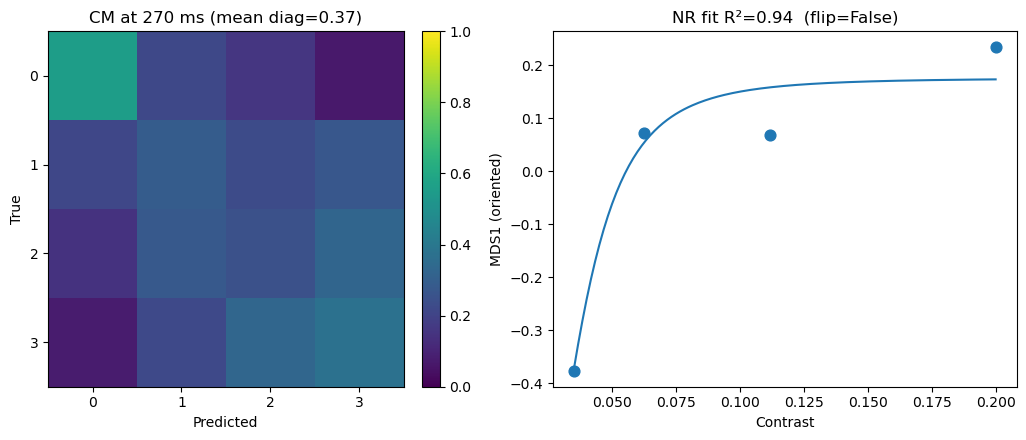

Peak time (ms): 269.5
MDS corr with contrast (after orientation): r=0.806, flipped=False
NR params: Rmax=1.16, c50=0.03392, n=3.52, R0=-0.986, R²=0.942, hit_bounds=True


In [29]:
# ==== C1: end-to-end on one subject ====
from pathlib import Path

# >>> EDIT THIS to your initial NPZ folder (the same you used before)
DATA_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ")
SUBJECT = "1001"   # <<< change if you want a different subject

# try to find the initial NPZ for this subject
cand = sorted(DATA_DIR.rglob(f"sub-{SUBJECT}_luminance_64_data.npz"))
assert cand, f"Couldn't find sub-{SUBJECT}_luminance_64_data.npz under {DATA_DIR}"
npz = np.load(cand[0], allow_pickle=True)
X = np.array(npz["X"], float)          # (trials, ch, time)
times = _ensure_seconds(npz["times"])
y = npz["event_codes"] if "event_codes" in npz else npz["y"]
y = _labels_to_0based(y)

# infer or reuse your window size/repeats/splits
WINDOW_SIZE = WINDOW_SIZE if "WINDOW_SIZE" in globals() and isinstance(WINDOW_SIZE, int) else 10
N_SPLITS = N_SPLITS if "N_SPLITS" in globals() else 5
N_REPEATS = N_REPEATS if "N_REPEATS" in globals() else 5

# 1) build confusion matrices over 80–300 ms
cm_out = compute_confusion_matrices_fixed(
    X, y, times,
    window_size=WINDOW_SIZE,
    time_range=PEAK_SEARCH,
    n_splits=N_SPLITS, n_repeats=N_REPEATS
)
tp = cm_out["time_points"]
cms = cm_out["confusion_matrices"]

# choose peak by mean diag (accuracy)
acc = np.array([np.trace(cm)/4.0 for cm in cms])
best_i = int(np.argmax(acc))
best_t = float(tp[best_i])
best_cm = cms[best_i]

# 2) MDS1 coordinate (oriented) at the peak
mds1, r_mds, flipped, D = mds_1d_from_cm(best_cm)

# 3) Robust 4p Naka–Rushton on that 1D coordinate
nr = fit_naka_rushton_robust(REAL_CONTRASTS, mds1)

# 4) Plots
fig, ax = plt.subplots(1,2, figsize=(11,4.5))

# Confusion matrix
im = ax[0].imshow(_row_normalize(best_cm), vmin=0, vmax=1)
ax[0].set_title(f"CM at {best_t*1000:.0f} ms (mean diag={acc[best_i]:.2f})")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
ax[0].set_xticks(range(4)); ax[0].set_yticks(range(4))
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# NR fit
x_fine = np.linspace(REAL_CONTRASTS.min(), REAL_CONTRASTS.max(), 200)
ax[1].plot(x_fine, naka_rushton_offset(x_fine, nr["Rmax"], nr["c50"], nr["n"], nr["R0"]))
ax[1].scatter(REAL_CONTRASTS, mds1, s=60)
ax[1].set_xlabel("Contrast"); ax[1].set_ylabel("MDS1 (oriented)")
ax[1].set_title(f"NR fit R²={nr['R2']:.2f}  (flip={flipped})")

plt.tight_layout()
plt.show()

print(f"Peak time (ms): {best_t*1000:.1f}")
print(f"MDS corr with contrast (after orientation): r={r_mds:.3f}, flipped={flipped}")
print(f"NR params: Rmax={nr['Rmax']:.3g}, c50={nr['c50']:.4g}, n={nr['n']:.3g}, R0={nr['R0']:.3g}, R²={nr['R2']:.3f}, hit_bounds={nr['hit_bounds']}")


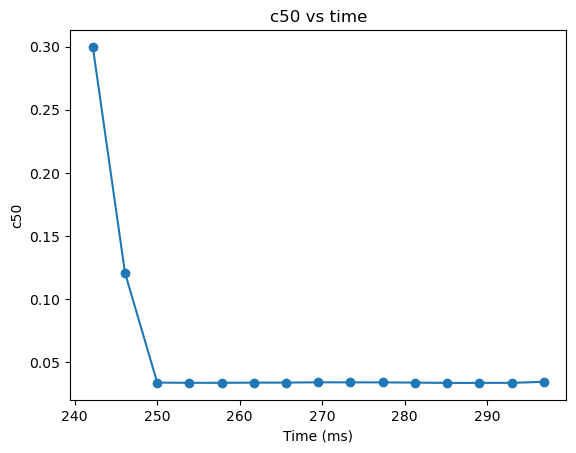

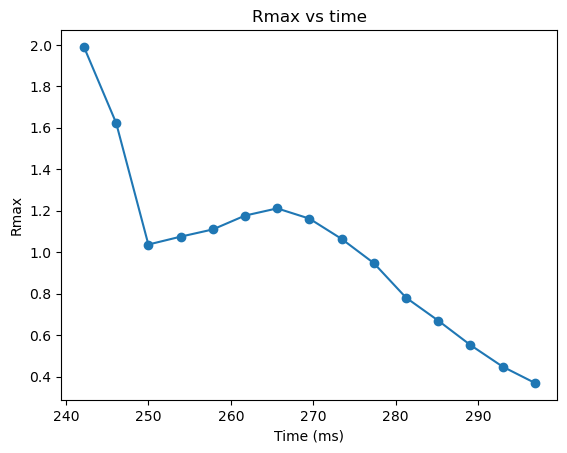

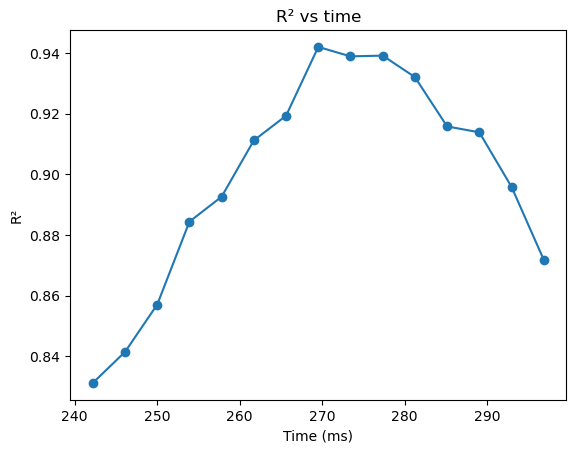

In [30]:
# D1 — sweep ±30 ms around the best time; track parameters & R²
import numpy as np, matplotlib.pyplot as plt

t = np.array(tp, float)
best_i = int(np.argmax([np.trace(cm)/4.0 for cm in cms]))
t0 = float(t[best_i])

# pick all timepoints within ±30 ms of t0
mask = (t >= t0 - 0.030) & (t <= t0 + 0.030)
t_sel = t[mask]

R2_list, c50_list, Rmax_list, n_list = [], [], [], []
for cm in np.array(cms, dtype=object)[mask]:
    mds1, r_mds, flipped, D = mds_1d_from_cm(cm)
    nr = fit_naka_rushton_robust(REAL_CONTRASTS, mds1)
    R2_list.append(nr["R2"])
    c50_list.append(nr["c50"])
    Rmax_list.append(nr["Rmax"])
    n_list.append(nr["n"])

plt.figure(); plt.plot(t_sel*1000, c50_list, marker="o"); plt.xlabel("Time (ms)"); plt.ylabel("c50"); plt.title("c50 vs time"); plt.show()
plt.figure(); plt.plot(t_sel*1000, Rmax_list, marker="o"); plt.xlabel("Time (ms)"); plt.ylabel("Rmax"); plt.title("Rmax vs time"); plt.show()
plt.figure(); plt.plot(t_sel*1000, R2_list, marker="o"); plt.xlabel("Time (ms)"); plt.ylabel("R²"); plt.title("R² vs time"); plt.show()


In [31]:
# D2 — batch across all subjects, collect robust NR fits at the best time
import pandas as pd

npz_list = sorted(DATA_DIR.rglob("sub-*_luminance_64_data.npz"))
rows = []

for p in npz_list:
    sid = p.name.split("_")[0].split("-")[1]
    d = np.load(p, allow_pickle=True)
    X = np.array(d["X"], float)
    times = _ensure_seconds(d["times"])
    y = d["event_codes"] if "event_codes" in d else d["y"]
    y = _labels_to_0based(y)

    out = compute_confusion_matrices_fixed(
        X, y, times,
        window_size=WINDOW_SIZE,
        time_range=PEAK_SEARCH,
        n_splits=N_SPLITS, n_repeats=N_REPEATS
    )
    tp, cms = out["time_points"], out["confusion_matrices"]
    acc = np.array([np.trace(cm)/4.0 for cm in cms])
    i = int(np.argmax(acc))
    cm_best = cms[i]
    mds1, r_mds, flipped, D = mds_1d_from_cm(cm_best)
    nr = fit_naka_rushton_robust(REAL_CONTRASTS, mds1)

    rows.append([sid, float(tp[i]), float(acc[i]), float(r_mds), flipped,
                 nr["Rmax"], nr["c50"], nr["n"], nr["R0"], nr["R2"], nr["hit_bounds"]])

batch = pd.DataFrame(rows, columns=["subject","t_peak_s","mean_diag","mds_r","flipped",
                                    "Rmax","c50","n","R0","R2","hit_bounds"])

print("=== Worst 10 by R² ===")
print(batch.sort_values("R2").head(10).to_string(index=False))
print("\nBound hits total:", int(batch.hit_bounds.sum()))


=== Worst 10 by R² ===
subject  t_peak_s  mean_diag    mds_r  flipped     Rmax      c50         n        R0       R2  hit_bounds
   1008  0.156250   0.436972 0.688367     True 0.427237 0.132403 10.000000 -0.121234 0.666589        True
   1002  0.171875   0.408333 0.609869     True 2.427125 0.236059 10.000000 -0.115650 0.682450        True
   1020  0.195312   0.378452 0.890056    False 1.840229 0.300000  0.531175 -0.625733 0.786477        True
   1052  0.167969   0.461370 0.907286    False 2.201312 0.300000  2.040913 -0.288683 0.793098        True
   1050  0.113281   0.325149 0.899405    False 1.074263 0.300000  1.721222 -0.160648 0.793436        True
   1041  0.277344   0.419137 0.909337    False 1.676618 0.300000  1.987179 -0.220622 0.806036        True
   1042  0.187500   0.445744 0.867643    False 1.488309 0.033761  2.102108 -1.167539 0.825252        True
   1064  0.164062   0.558155 0.904556    False 4.611566 0.300000  0.555184 -1.549464 0.826485        True
   1007  0.144531   0.4

In [33]:
# D2b — batch refit with global n* and c50 upper bound = 5×max(contrast)
rows2 = []
for sid, v in per_subject.items():
    fixed = fit_with_fixed_n_wide(REAL_CONTRASTS, v["mds1"], n_fixed=n_star, c50_hi_factor=5.0)
    rows2.append([sid, v["t_peak"], v["acc_peak"], fixed["R2"], fixed["c50"], fixed["Rmax"], fixed["R0"], fixed["hit_bounds"]])
batch_fixed = pd.DataFrame(rows2, columns=["subject","t_peak_s","mean_diag","R2","c50","Rmax","R0","hit_bounds"])

print("=== Worst 10 by R² (fixed n) ===")
print(batch_fixed.sort_values("R2").head(10).to_string(index=False))
print("\nBound hits total (fixed n):", int(batch_fixed.hit_bounds.sum()))


=== Worst 10 by R² (fixed n) ===
subject  t_peak_s  mean_diag       R2      c50     Rmax        R0  hit_bounds
   1002  0.171875   0.408333 0.627350 0.298029 2.427496 -0.141972        True
   1007  0.144531   0.420000 0.642659 0.077592 0.416759 -0.250017       False
   1008  0.156250   0.436972 0.654275 0.318269 2.983029 -0.103644        True
   1064  0.164062   0.558155 0.709793 0.137816 1.107754 -0.377048       False
   1020  0.195312   0.378452 0.738278 0.172447 0.513887 -0.109765       False
   1029  0.117188   0.385982 0.765246 0.136732 0.688398 -0.221027       False
   1044  0.136719   0.453333 0.767065 0.048989 0.864334 -0.598953       False
   1010  0.207031   0.449583 0.767204 0.032254 1.302787 -1.178431        True
   1050  0.113281   0.325149 0.771156 0.185415 0.523145 -0.095528       False
   1038  0.132812   0.349807 0.772266 0.053725 0.446383 -0.298884       False

Bound hits total (fixed n): 13


In [34]:
# D2c — final refit with n = n_star, ±1 window smoothing, wider c50 bounds, and full QC export

import numpy as np, pandas as pd
from scipy.optimize import least_squares
from pathlib import Path

# 1) Helper: fixed-n fitter that also returns WHICH bound was hit (if any)
def fit_with_fixed_n_inspect(contrasts, responses, n_fixed=4.0, c50_hi_factor=10.0):
    x = np.asarray(contrasts, float)
    y = np.asarray(responses, float)
    eps = 1e-12

    # orient
    cc = np.corrcoef(x, y)[0,1] if np.isfinite(np.corrcoef(x, y)[0,1]) else np.nan
    if np.isfinite(cc) and cc < 0:
        y = -y

    # sort
    idx = np.argsort(x); x, y = x[idx], y[idx]

    rng_y = float(np.nanmax(y) - np.nanmin(y) + eps)
    R0_guess   = float(np.nanmin(y))
    Rmax_guess = max(float(np.nanmax(y) - R0_guess), eps)
    c50_guess  = float(np.sqrt(np.nanmin(x) * np.nanmax(x)))

    def model(p):
        Rmax, c50, R0 = p
        return R0 + Rmax*(x**n_fixed)/(x**n_fixed + c50**n_fixed)

    def resid(p): return model(p) - y

    lo = np.array([0.0,           np.nanmin(x)*0.25,  np.nanmin(y)-rng_y])
    hi = np.array([rng_y*5.0,     np.nanmax(x)*c50_hi_factor,  np.nanmax(y)+rng_y])

    res = least_squares(resid, x0=[Rmax_guess, c50_guess, R0_guess],
                        bounds=(lo, hi), loss='soft_l1', f_scale=0.1, max_nfev=5000)
    p = res.x; yhat = model(p)
    r2 = 1 - np.sum((y - yhat)**2)/max(eps, np.sum((y - np.nanmean(y))**2))

    # which bound?
    tol = 1e-9
    hits = []
    labels = ["Rmax_lo","c50_lo","R0_lo","Rmax_hi","c50_hi","R0_hi"]
    hits_mask = np.concatenate([np.isclose(p, lo, atol=tol), np.isclose(p, hi, atol=tol)])
    for lab, h in zip(labels, hits_mask):
        if h: hits.append(lab)
    hit_any = bool(len(hits) > 0)

    return {
        "Rmax":p[0], "c50":p[1], "R0":p[2], "n":n_fixed, "R2":float(r2),
        "hit_bounds":hit_any, "bound_which":";".join(hits)
    }

# 2) Build per-subject MDS1 at subject-specific peak, with ±1 window smoothing
def cm_smooth_around(cms, i, neighbors=1):
    i0 = max(0, i - neighbors)
    i1 = min(len(cms), i + neighbors + 1)
    cm_sum = np.zeros_like(cms[0], dtype=float)
    for k in range(i0, i1):
        cm_sum += cms[k]
    return cm_sum / float(i1 - i0)

npz_list = sorted(DATA_DIR.rglob("sub-*_luminance_64_data.npz"))
rows = []

for p in npz_list:
    sid = p.name.split("_")[0].split("-")[1]
    d = np.load(p, allow_pickle=True)
    X = np.array(d["X"], float)
    times = _ensure_seconds(d["times"])
    y = d["event_codes"] if "event_codes" in d else d["y"]
    y = _labels_to_0based(y)

    out = compute_confusion_matrices_fixed(
        X, y, times,
        window_size=WINDOW_SIZE,
        time_range=PEAK_SEARCH,
        n_splits=N_SPLITS, n_repeats=N_REPEATS
    )
    tp, cms = out["time_points"], out["confusion_matrices"]
    acc = np.array([np.trace(cm)/4.0 for cm in cms])
    i = int(np.argmax(acc))

    cm_best = cm_smooth_around(cms, i, neighbors=1)  # ±1 window smoothing
    mds1, r_mds, flipped, D = mds_1d_from_cm(cm_best)

    fit = fit_with_fixed_n_inspect(REAL_CONTRASTS, mds1, n_fixed=4.0, c50_hi_factor=10.0)

    rows.append([
        sid, float(tp[i]), float(acc[i]), float(r_mds), bool(flipped),
        fit["Rmax"], fit["c50"], fit["R0"], fit["n"], fit["R2"],
        bool(fit["hit_bounds"]), fit["bound_which"]
    ])

final_df = pd.DataFrame(rows, columns=[
    "subject","t_peak_s","mean_diag","mds_r","flipped",
    "Rmax","c50","R0","n","R2","hit_bounds","bound_which"
])

# 3) QC prints
print("=== Worst 10 by R² (final) ===")
print(final_df.sort_values("R2").head(10).to_string(index=False))
print("\nBound hits total (final):", int(final_df.hit_bounds.sum()))

# where are the hits?
if final_df.hit_bounds.any():
    print("\nBound types (counts):")
    print(final_df.loc[final_df.hit_bounds, "bound_which"].value_counts().to_string())

# interpretability helpers
cmax = float(REAL_CONTRASTS.max())
n_over = int((final_df["c50"] > cmax).sum())
print(f"\nSubjects with c50 > max(contrast) [{cmax:.3f}]: {n_over} / {len(final_df)}")

# 4) Export
OUT = Path.cwd() / "NR_fits_n4_smooth.csv"
final_df.to_csv(OUT, index=False)
print(f"\nSaved CSV → {OUT}")


=== Worst 10 by R² (final) ===
subject  t_peak_s  mean_diag    mds_r  flipped     Rmax      c50        R0   n       R2  hit_bounds bound_which
   1008  0.156250   0.436972 0.618837     True 0.341665 0.085444 -0.154515 4.0 0.567294       False            
   1002  0.171875   0.408333 0.607089     True 2.394065 0.299566 -0.136870 4.0 0.620053        True     Rmax_hi
   1007  0.144531   0.420000 0.597230     True 0.409385 0.077439 -0.244913 4.0 0.646240       False            
   1020  0.195312   0.378452 0.882289    False 0.425055 0.153432 -0.111766 4.0 0.702421       False            
   1064  0.164062   0.558155 0.905255    False 1.095528 0.137883 -0.371867 4.0 0.712277       False            
   1010  0.207031   0.449583 0.418431     True 1.271148 0.032185 -1.150956 4.0 0.759553        True       R0_lo
   1029  0.117188   0.385982 0.921764    False 0.683824 0.137116 -0.218316 4.0 0.767373       False            
   1052  0.167969   0.461370 0.910175    False 0.861882 0.163475 -0.21052

In [32]:
# D3-GLOBAL — pick a global n that maximizes median R² across subjects
import numpy as np, pandas as pd

# helper: fixed-n fitter with wider c50 bounds
from scipy.optimize import least_squares
def fit_with_fixed_n_wide(contrasts, responses, n_fixed=2.0, c50_hi_factor=5.0):
    x = np.asarray(contrasts, float)
    y = np.asarray(responses, float)
    eps = 1e-12
    # orient
    cc = np.corrcoef(x, y)[0,1] if np.isfinite(np.corrcoef(x, y)[0,1]) else np.nan
    if np.isfinite(cc) and cc < 0: y = -y
    # sort
    idx = np.argsort(x); x, y = x[idx], y[idx]
    rng_y = float(np.nanmax(y) - np.nanmin(y) + eps)
    R0_guess   = float(np.nanmin(y))
    Rmax_guess = max(float(np.nanmax(y) - R0_guess), eps)
    c50_guess  = float(np.sqrt(np.nanmin(x)*np.nanmax(x)))

    def model(p):
        Rmax, c50, R0 = p
        return R0 + Rmax*(x**n_fixed)/(x**n_fixed + c50**n_fixed)
    def resid(p): return model(p) - y

    lo = np.array([0.0,           np.nanmin(x)*0.25,  np.nanmin(y)-rng_y])
    hi = np.array([rng_y*5.0,     np.nanmax(x)*c50_hi_factor,  np.nanmax(y)+rng_y])

    res = least_squares(resid, x0=[Rmax_guess, c50_guess, R0_guess],
                        bounds=(lo, hi), loss='soft_l1', f_scale=0.1, max_nfev=5000)
    p = res.x; yhat = model(p)
    r2 = 1 - np.sum((y - yhat)**2)/max(eps, np.sum((y - np.nanmean(y))**2))
    hit_bounds = bool(np.isclose(p, lo, atol=1e-10).any() or np.isclose(p, hi, atol=1e-10).any())
    return {"Rmax":p[0], "c50":p[1], "R0":p[2], "R2":float(r2), "hit_bounds":hit_bounds}

# build per-subject MDS1 at the subject-specific peak (reuse your batch loop logic)
rows = []
npz_list = sorted(DATA_DIR.rglob("sub-*_luminance_64_data.npz"))
per_subject = {}  # sid -> dict with MDS1 at peak, etc.

for p in npz_list:
    sid = p.name.split("_")[0].split("-")[1]
    d = np.load(p, allow_pickle=True)
    X = np.array(d["X"], float)
    times = _ensure_seconds(d["times"])
    y = d["event_codes"] if "event_codes" in d else d["y"]
    y = _labels_to_0based(y)

    out = compute_confusion_matrices_fixed(
        X, y, times,
        window_size=WINDOW_SIZE,
        time_range=PEAK_SEARCH,
        n_splits=N_SPLITS, n_repeats=N_REPEATS
    )
    tp, cms = out["time_points"], out["confusion_matrices"]
    acc = np.array([np.trace(cm)/4.0 for cm in cms])
    i = int(np.argmax(acc))
    cm_best = cms[i]
    mds1, r_mds, flipped, D = mds_1d_from_cm(cm_best)
    per_subject[sid] = {"mds1": mds1, "t_peak": float(tp[i]), "acc_peak": float(acc[i])}

# grid search n
n_grid = np.arange(0.75, 4.25, 0.25)  # you can widen if needed
stats = []
for n_fixed in n_grid:
    fits = []
    hits = 0
    for sid, v in per_subject.items():
        nr = fit_with_fixed_n_wide(REAL_CONTRASTS, v["mds1"], n_fixed=n_fixed, c50_hi_factor=5.0)
        fits.append(nr["R2"])
        hits += int(nr["hit_bounds"])
    stats.append([n_fixed, float(np.median(fits)), float(np.mean(fits)), int(hits)])
grid = pd.DataFrame(stats, columns=["n","median_R2","mean_R2","bound_hits"])
print(grid.sort_values("median_R2", ascending=False).to_string(index=False))

# pick the best n by median R²
n_star = float(grid.sort_values("median_R2", ascending=False).iloc[0]["n"])
print(f"\nChosen global n* = {n_star}")


   n  median_R2  mean_R2  bound_hits
4.00   0.843246 0.825432          13
2.00   0.827386 0.782637          23
2.50   0.827342 0.798009          17
2.25   0.826184 0.790934          21
3.75   0.825978 0.822085          14
2.75   0.825855 0.804096          15
1.75   0.822757 0.773197          24
3.00   0.818436 0.809387          14
3.25   0.816311 0.814102          14
3.50   0.815030 0.818319          14
1.50   0.814609 0.762363          24
1.25   0.807972 0.750041          26
1.00   0.800865 0.736544          27
0.75   0.789884 0.718510          33

Chosen global n* = 4.0


In [4]:

# ## 3. ECOC Decoding for All Subjects

# %%
# Run ECOC decoding for each subject
subject_results = {}
for subject in SUBJECTS:
    print(f"\nProcessing subject: {subject}")
    try:
        # Load data
        X, y, times = load_subject_data(subject)
        
        # Run decoding
        results = run_ecoc_decoding(X, y, times)
        
        # Save results
        np.savez(RESULTS_DIR / f"sub-{subject}_ecoc_results.npz", 
                time_decoder=results['time_decoder'],
                accuracies=results['accuracies'])
        
        subject_results[subject] = results
        print(f"Max accuracy: {np.max(results['accuracies']):.3f}")
    except Exception as e:
        print(f"Error processing {subject}: {e}")

# Compute group average
if subject_results:
    time_points = list(subject_results.values())[0]['time_decoder']
    group_acc = np.mean([res['accuracies'] for res in subject_results.values()], axis=0)
    np.savez(RESULTS_DIR / "group_ecoc_results.npz", 
             time_decoder=time_points, 
             accuracies=group_acc)





Processing subject: 1001


Repetitions: 100%|██████████| 10/10 [01:46<00:00, 10.63s/it]


Max accuracy: 0.352

Processing subject: 1002


Repetitions: 100%|██████████| 10/10 [01:47<00:00, 10.78s/it]


Max accuracy: 0.405

Processing subject: 1004


...

Max accuracy: 0.385

Processing subject: 1059


Repetitions: 100%|██████████| 10/10 [01:55<00:00, 11.58s/it]


Max accuracy: 0.367

Processing subject: 1064


Repetitions: 100%|██████████| 10/10 [01:59<00:00, 11.94s/it]

Max accuracy: 0.565



Computing confusion matrices for 1001


Time windows: 100%|██████████| 64/64 [00:36<00:00,  1.77it/s]


Using subject's peak time: 0.266s
Displaying confusion matrix at 0.266s


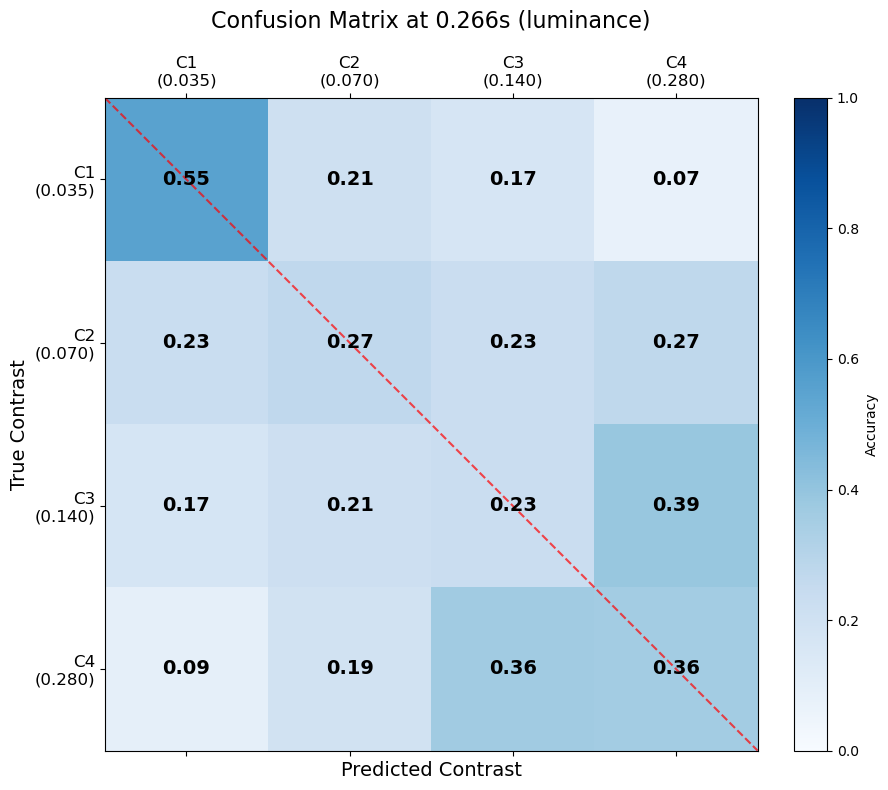

In [ ]:
# ## 4. Confusion Matrix Analysis 


# Select sample subject
sample_subject = "1001"
print(f"\nComputing confusion matrices for {sample_subject}")

# Load data
X, y, times = load_subject_data(sample_subject)

# Compute confusion matrices in time range
cm_results = compute_confusion_matrices_fixed(X, y, times, window_size=WINDOW_SIZE, time_range=(0.080, 0.300),
                                 n_splits=N_SPLITS, n_repeats=N_REPEATS)


# Find peak time - use subject's own peak if available
if sample_subject in subject_results:
    # Get subject's accuracy results
    subject_acc = subject_results[sample_subject]['accuracies']
    subject_times = subject_results[sample_subject]['time_decoder']
    
    # Find peak within our time range
    in_range = (subject_times >= TIME_RANGE[0]) & (subject_times <= TIME_RANGE[1])
    peak_idx = np.argmax(subject_acc[in_range])
    peak_time = subject_times[in_range][peak_idx]
    print(f"Using subject's peak time: {peak_time:.3f}s")
elif 'group_acc' in locals():
    # Fallback to group peak time
    peak_idx = np.argmax(group_acc)
    peak_time = time_points[peak_idx]
    print(f"Using group peak time: {peak_time:.3f}s")
else:
    # Fallback to middle of time range
    peak_time = np.mean(TIME_RANGE)
    print(f"Using middle of time range: {peak_time:.3f}s")

# Find closest time in confusion matrix results
cm_time_idx = np.argmin(np.abs(cm_results['time_points'] - peak_time))
cm = cm_results['confusion_matrices'][cm_time_idx]
cm_time = cm_results['time_points'][cm_time_idx]
print(f"Displaying confusion matrix at {cm_time:.3f}s")

# Define confusion matrix plotting function
def plot_confusion_matrix(cm, contrast_levels, analysis_name, time_point, save_path=None):
    """Plot confusion matrix with annotations and color coding"""
    fig, ax = plt.subplots(figsize=(10, 8))
    cax = ax.matshow(cm, cmap='Blues', vmin=0, vmax=1)
    fig.colorbar(cax, fraction=0.046, pad=0.04, label='Accuracy')
    
    # Set labels and ticks
    ax.set_xlabel('Predicted Contrast', fontsize=14)
    ax.set_ylabel('True Contrast', fontsize=14)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels([f'C{i+1}\n({c:.3f})' for i, c in enumerate(contrast_levels)], fontsize=12)
    ax.set_yticklabels([f'C{i+1}\n({c:.3f})' for i, c in enumerate(contrast_levels)], fontsize=12)
    
    # Add annotations
    for i in range(4):
        for j in range(4):
            color = 'white' if cm[i, j] > 0.6 else 'black'
            ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center', 
                    color=color, fontsize=14, fontweight='bold')
    
    # Add diagonal line
    ax.plot([-0.5, 3.5], [-0.5, 3.5], 'r--', alpha=0.7)
    plt.title(f'Confusion Matrix at {time_point:.3f}s ({analysis_name})', fontsize=16, pad=20)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(
    cm, 
    CONTRASTS[ANALYSIS_NAME], 
    ANALYSIS_NAME, 
    cm_time,
    save_path=RESULTS_DIR / f"sub-{sample_subject}_confusion_matrix_{cm_time:.3f}s.png"
)


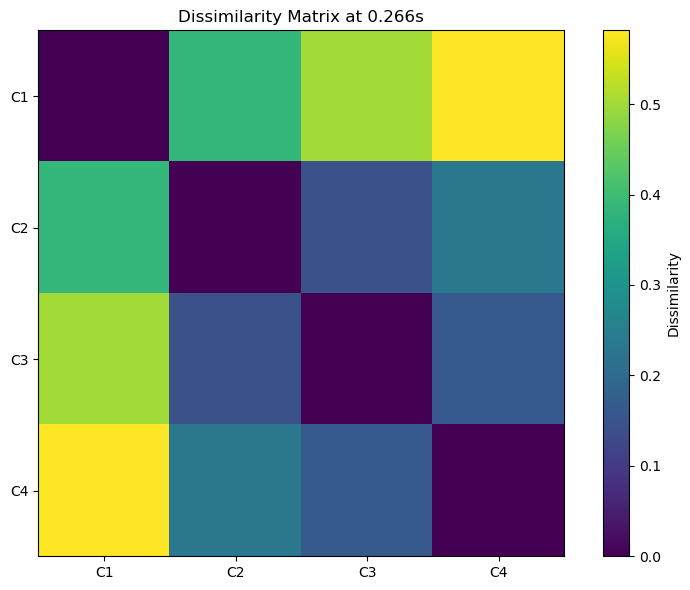

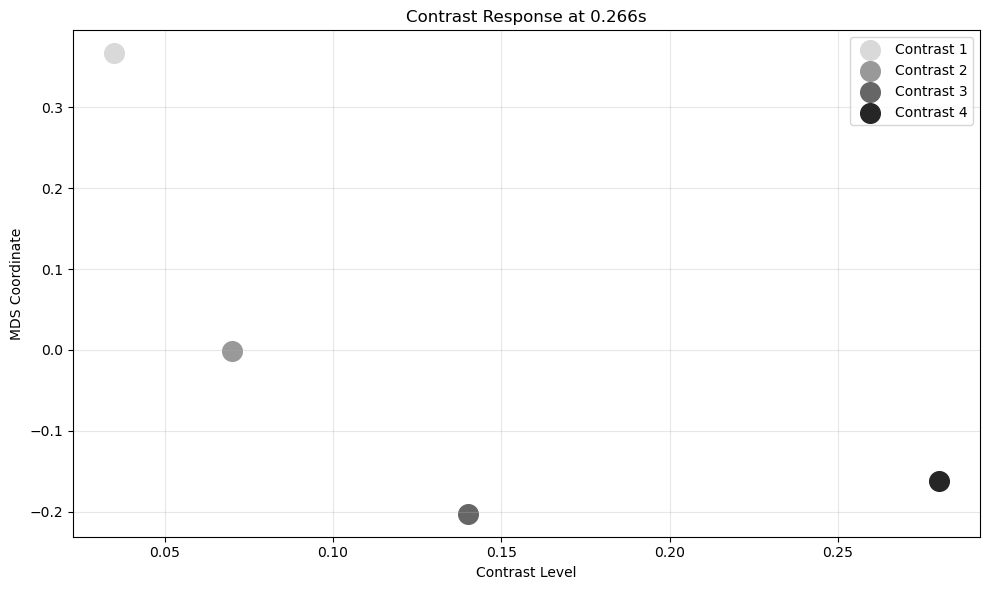

Naka-Rushton parameters: R_max=0.00, c50=0.2800, n=0.50


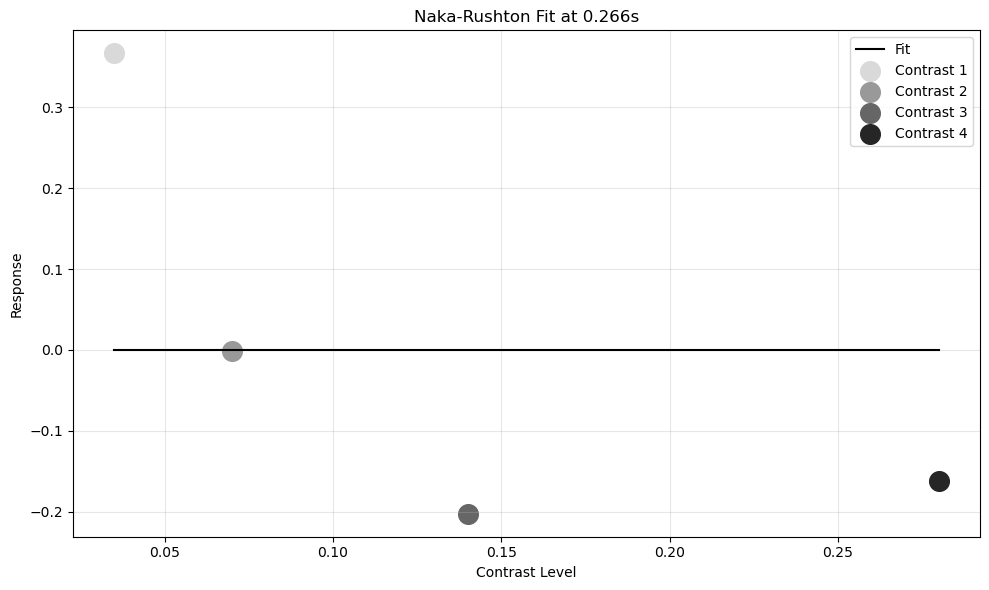

In [ ]:
# ## 5. Contrast Response Modeling

# %%
# Check if we have a confusion matrix to work with
if 'cm' in locals() and cm is not None:
    # Compute MDS coordinates
    mds1, r_mds, flipped, D = mds_1d_from_cm(cm)

    
    # Plot dissimilarity matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(dissimilarity, cmap='viridis')
    plt.colorbar(label='Dissimilarity')
    plt.title(f"Dissimilarity Matrix at {cm_time:.3f}s")
    plt.xticks(range(4), ['C1', 'C2', 'C3', 'C4'])
    plt.yticks(range(4), ['C1', 'C2', 'C3', 'C4'])
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"sub-{sample_subject}_dissimilarity.png", dpi=150)
    plt.show()
    
    # Plot contrast response
    plt.figure(figsize=(10, 6))
    for i in range(4):
        plt.scatter(CONTRASTS[ANALYSIS_NAME][i], mds_coords[i], 
                   s=200, color=COLORS[ANALYSIS_NAME][i],
                   label=f'Contrast {i+1}')
    plt.xlabel('Contrast Level')
    plt.ylabel('MDS Coordinate')
    plt.title(f"Contrast Response at {cm_time:.3f}s")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{sample_subject}_contrast_response.png", dpi=150)
    plt.show()
    
    # Fit Naka-Rushton function
    params = fit_naka_rushton(CONTRASTS[ANALYSIS_NAME], mds_coords)
    
    # Check if fitting was successful
    if params is not None:
        print(f"Naka-Rushton parameters: R_max={params[0]:.2f}, c50={params[1]:.4f}, n={params[2]:.2f}")
        
        # Plot fit
        fine_contrast = np.linspace(min(CONTRASTS[ANALYSIS_NAME]), max(CONTRASTS[ANALYSIS_NAME]), 100)
        predicted = naka_rushton(fine_contrast, *params)
        
        plt.figure(figsize=(10, 6))
        plt.plot(fine_contrast, predicted, 'k-', label='Fit')
        for i in range(4):
            plt.scatter(CONTRASTS[ANALYSIS_NAME][i], mds_coords[i], 
                       s=200, color=COLORS[ANALYSIS_NAME][i],
                       label=f'Contrast {i+1}')
        plt.xlabel('Contrast Level')
        plt.ylabel('Response')
        plt.title(f"Naka-Rushton Fit at {cm_time:.3f}s")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(RESULTS_DIR / f"{sample_subject}_naka_rushton_fit.png", dpi=150)
        plt.show()
    else:
        print("Naka-Rushton fitting failed")
else:
    print("Skipping contrast response modeling - no confusion matrix available")

Computing MDS: 100%|██████████| 64/64 [00:00<00:00, 721.94it/s]


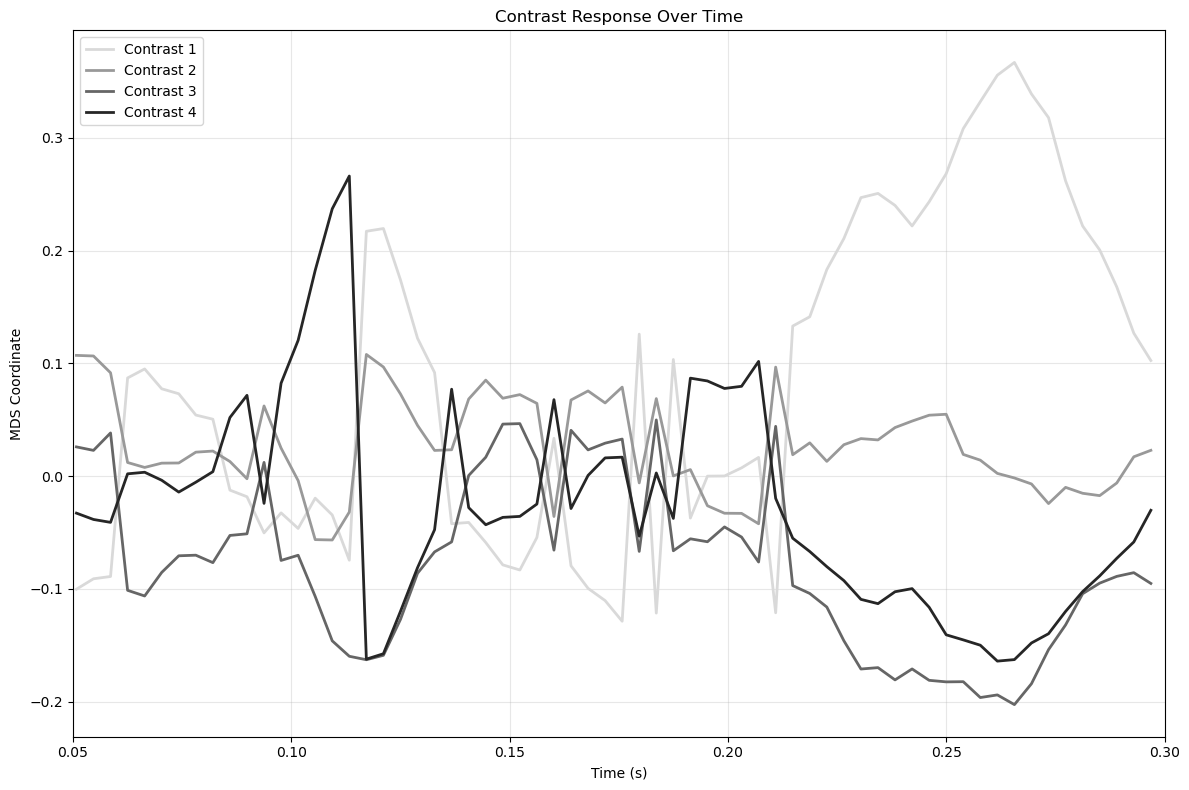

In [ ]:

# ## 6. Time-Resolved Contrast Response

# %%
if 'cm_results' in locals():
    # Compute MDS coordinates over time
    mds_over_time = []
    for cm in tqdm(cm_results['confusion_matrices'], desc="Computing MDS"):
        coords, _ = mds_1d_from_cm(cm)

        mds_over_time.append(coords)
    mds_over_time = np.array(mds_over_time)
    
    # Plot results
    plt.figure(figsize=(12, 8))
    for i in range(4):
        plt.plot(cm_results['time_points'], mds_over_time[:, i], 
                 color=COLORS[ANALYSIS_NAME][i], 
                 linewidth=2, label=f'Contrast {i+1}')
    plt.xlabel('Time (s)')
    plt.ylabel('MDS Coordinate')
    plt.title('Contrast Response Over Time')
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlim(TIME_RANGE[0], TIME_RANGE[1])
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{sample_subject}_contrast_response_over_time.png", dpi=150)
    plt.show()


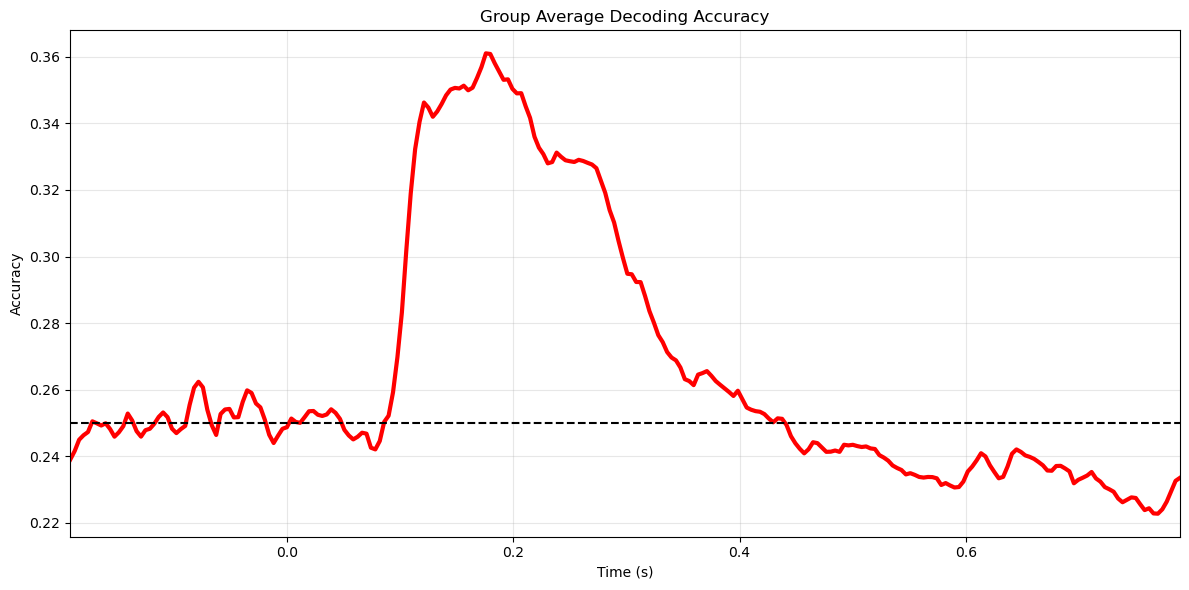

In [10]:

# ## 7. Group-Level Visualization

# %%
# Load group results if available
if os.path.exists(RESULTS_DIR / "group_ecoc_results.npz"):
    group_data = np.load(RESULTS_DIR / "group_ecoc_results.npz")
    time_points = group_data['time_decoder']
    group_acc = group_data['accuracies']
    
    # Plot group decoding accuracy
    plt.figure(figsize=(12, 6))
    plt.plot(time_points, group_acc, 'r-', linewidth=3)
    plt.axhline(0.25, color='k', linestyle='--', label='Chance')
    plt.xlabel('Time (s)')
    plt.ylabel('Accuracy')
    plt.title('Group Average Decoding Accuracy')
    plt.grid(alpha=0.3)
    plt.xlim(time_points[0], time_points[-1])
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "group_decoding_accuracy.png", dpi=150)
    plt.show()





Subject 1001 (Age 24.43): Peak Acc=0.352 at 0.266s
Subject 1002 (Age 43.26): Peak Acc=0.405 at 0.215s
Subject 1004 (Age 32.89): Peak Acc=0.382 at 0.215s
Subject 1005 (Age 50.02): Peak Acc=0.439 at 0.164s
Subject 1007 (Age 30.94): Peak Acc=0.433 at 0.145s
Subject 1008 (Age 24.42): Peak Acc=0.445 at 0.156s
Subject 1010 (Age 25.53): Peak Acc=0.456 at 0.207s
Subject 1011 (Age 36.71): Peak Acc=0.485 at 0.207s
Subject 1014 (Age 23.14): Peak Acc=0.430 at 0.145s
Subject 1015 (Age 34.18): Peak Acc=0.414 at 0.180s
Subject 1018 (Age 25.6): Peak Acc=0.322 at -0.074s
Subject 1020 (Age 29.49): Peak Acc=0.383 at 0.195s
Subject 1021 (Age 27.81): Peak Acc=0.339 at 0.121s
Subject 1022 (Age 31.22): Peak Acc=0.398 at 0.195s
Subject 1023 (Age 45.99): Peak Acc=0.344 at 0.133s
Subject 1024 (Age 24.31): Peak Acc=0.404 at 0.145s
Subject 1026 (Age 24.93): Peak Acc=0.495 at 0.164s
Subject 1028 (Age 61.46): Peak Acc=0.323 at -0.082s
Subject 1029 (Age 32.27): Peak Acc=0.396 at 0.117s
Subject 1031 (Age 57.86): Peak

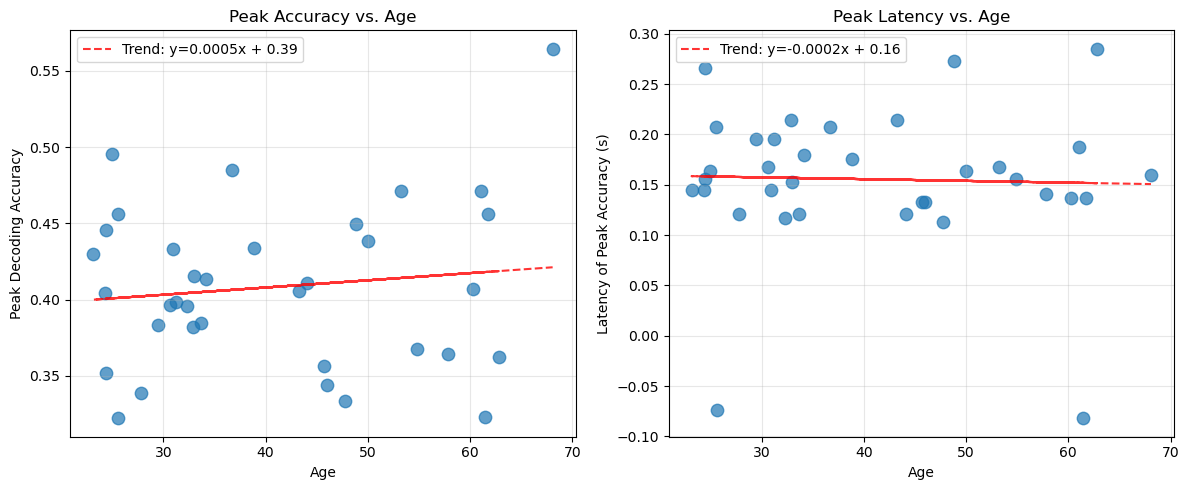


Correlation Coefficient (Age vs. Peak Accuracy): 0.121
Correlation Coefficient (Age vs. Peak Latency): -0.033


In [11]:
# %%
# ----------------------------------------------------------------------------------
# 8. Exploratory Analysis: Correlation with Age
# ----------------------------------------------------------------------------------

# Analysis parameters
ANALYSIS_NAME = "luminance"     
ELECTRODE_SET = "64"             
# subject list 
SUBJECTS = ["1001", "1002", "1004", "1005", "1007", "1008", "1010", "1011", "1014", "1015", 
            "1018", "1020", "1021", "1022", "1023", "1024", "1026", "1028", "1029", "1031",
            "1033", "1034", "1037", "1038", "1039", "1041", "1042", "1044", "1046", "1049",
            "1050", "1052", "1057", "1059", "1064"]

# Participant age data (map subject code to age at enrolment
AGE_DATA = {
    "1001": 24.43,
    "1002": 43.26,
    "1004": 32.89,
    "1005": 50.02,
    "1007": 30.94,
    "1008": 24.42,
    "1010": 25.53,
    "1011": 36.71,
    "1014": 23.14,
    "1015": 34.18,
    "1018": 25.60,
    "1020": 29.49,
    "1021": 27.81,
    "1022": 31.22,
    "1023": 45.99,
    "1024": 24.31,
    "1026": 24.93,
    "1028": 61.46,
    "1029": 32.27,
    "1031": 57.86,
    "1033": 30.65,
    "1034": 60.27,
    "1037": 32.98,
    "1038": 45.69,
    "1039": 62.81,
    "1041": 48.86,
    "1042": 38.84,
    "1044": 61.74,
    "1046": 61.07,
    "1049": 44.08,
    "1050": 47.77,
    "1052": 53.22,
    "1057": 33.69,
    "1059": 54.85,
    "1064": 68.08
}
subject_metrics = []

for subject in SUBJECTS:
    try:
        # 1. Load the subject's decoding results
        ecoc_file = RESULTS_DIR / f"sub-{subject}_ecoc_results.npz"
        subject_data = np.load(ecoc_file)
        time_vec = subject_data['time_decoder']
        acc_vec = subject_data['accuracies']

        # 2. Find the peak accuracy and its latency
        peak_acc = np.max(acc_vec)
        peak_time = time_vec[np.argmax(acc_vec)]


        # 4. Get the subject's age
        age = AGE_DATA.get(subject, None)
        if age is None:
            print(f"Warning: Age not found for subject {subject}. Skipping.")
            continue

        # 5. Store the metrics
        subject_metrics.append({
            'subject': subject,
            'age': age,
            'peak_accuracy': peak_acc,
            'peak_latency': peak_time
        })
        print(f"Subject {subject} (Age {age}): Peak Acc={peak_acc:.3f} at {peak_time:.3f}s")

    except FileNotFoundError:
        print(f"Results not found for subject {subject}. Skipping.")
    except Exception as e:
        print(f"Error processing subject {subject} for age analysis: {e}")

# Convert the list of metrics to a DataFrame for easier analysis
import pandas as pd
df_metrics = pd.DataFrame(subject_metrics)

# Check if we have data to plot
if len(df_metrics) > 1:
    # Plot Peak Accuracy vs. Age
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.scatter(df_metrics['age'], df_metrics['peak_accuracy'], s=80, alpha=0.7)
    plt.xlabel('Age')
    plt.ylabel('Peak Decoding Accuracy')
    plt.title('Peak Accuracy vs. Age')
    
    # Add a trendline
    z = np.polyfit(df_metrics['age'], df_metrics['peak_accuracy'], 1)
    p = np.poly1d(z)
    plt.plot(df_metrics['age'], p(df_metrics['age']), "r--", alpha=0.8, 
             label=f'Trend: y={z[0]:.4f}x + {z[1]:.2f}')
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot Peak Latency vs. Age
    plt.subplot(1, 2, 2)
    plt.scatter(df_metrics['age'], df_metrics['peak_latency'], s=80, alpha=0.7)
    plt.xlabel('Age')
    plt.ylabel('Latency of Peak Accuracy (s)')
    plt.title('Peak Latency vs. Age')
    
    # Add a trendline
    z = np.polyfit(df_metrics['age'], df_metrics['peak_latency'], 1)
    p = np.poly1d(z)
    plt.plot(df_metrics['age'], p(df_metrics['age']), "r--", alpha=0.8, 
             label=f'Trend: y={z[0]:.4f}x + {z[1]:.2f}')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "age_correlation_analysis.png", dpi=150)
    plt.show()

    # Calculate and print correlation coefficients
    corr_acc = df_metrics['age'].corr(df_metrics['peak_accuracy'])
    corr_lat = df_metrics['age'].corr(df_metrics['peak_latency'])
    
    print(f"\nCorrelation Coefficient (Age vs. Peak Accuracy): {corr_acc:.3f}")
    print(f"Correlation Coefficient (Age vs. Peak Latency): {corr_lat:.3f}")

else:
    print("Not enough data to perform correlation analysis with age.")


Results saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results/luminance_age_correlation_results.csv
Correlation coefficients saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results/luminance_correlation_coefficients.txt


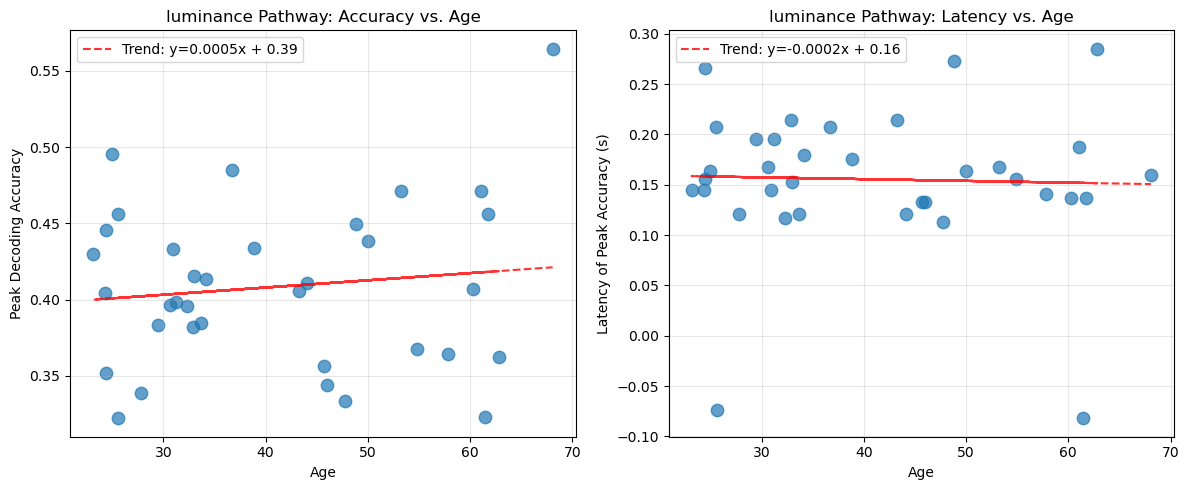

Plot saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Decoding_VEP/Decoding_VEP/Luminance_NPZ/ecoc_results/luminance_age_correlation_analysis.png

SUMMARY FOR LUMINANCE PATHWAY
Number of subjects: 35
Average peak accuracy: 0.408
Average peak latency: 0.155s
Correlation (Age vs. Accuracy): 0.121
Correlation (Age vs. Latency): -0.033


In [17]:
# ----------------------------------------------------------------------------------
# 9. Save Results for Current Pathway
# ----------------------------------------------------------------------------------

# Save the metrics DataFrame to a CSV file
results_filename = f"{ANALYSIS_NAME}_age_correlation_results.csv"
df_metrics.to_csv(RESULTS_DIR / results_filename, index=False)
print(f"\nResults saved to: {RESULTS_DIR / results_filename}")

# Save correlation coefficients to a text file
corr_filename = f"{ANALYSIS_NAME}_correlation_coefficients.txt"
with open(RESULTS_DIR / corr_filename, 'w') as f:
    f.write(f"Analysis for {ANALYSIS_NAME} pathway\n")
    f.write("=" * 40 + "\n\n")
    f.write(f"Correlation Coefficient (Age vs. Peak Accuracy): {corr_acc:.3f}\n")
    f.write(f"Correlation Coefficient (Age vs. Peak Latency): {corr_lat:.3f}\n\n")
    
    f.write("Individual Subject Results:\n")
    f.write("=" * 40 + "\n")
    for _, row in df_metrics.iterrows():
        f.write(f"Subject {row['subject']} (Age {row['age']}): "
                f"Peak Acc={row['peak_accuracy']:.3f} at {row['peak_latency']:.3f}s\n")

print(f"Correlation coefficients saved to: {RESULTS_DIR / corr_filename}")

# Save a summary plot with the pathway name in the filename
plot_filename = f"{ANALYSIS_NAME}_age_correlation_analysis.png"
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_metrics['age'], df_metrics['peak_accuracy'], s=80, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Peak Decoding Accuracy')
plt.title(f'{ANALYSIS_NAME} Pathway: Accuracy vs. Age')

# Add a trendline
z = np.polyfit(df_metrics['age'], df_metrics['peak_accuracy'], 1)
p = np.poly1d(z)
plt.plot(df_metrics['age'], p(df_metrics['age']), "r--", alpha=0.8, 
         label=f'Trend: y={z[0]:.4f}x + {z[1]:.2f}')
plt.legend()
plt.grid(alpha=0.3)

# Plot Peak Latency vs. Age
plt.subplot(1, 2, 2)
plt.scatter(df_metrics['age'], df_metrics['peak_latency'], s=80, alpha=0.7)
plt.xlabel('Age')
plt.ylabel('Latency of Peak Accuracy (s)')
plt.title(f'{ANALYSIS_NAME} Pathway: Latency vs. Age')

# Add a trendline
z = np.polyfit(df_metrics['age'], df_metrics['peak_latency'], 1)
p = np.poly1d(z)
plt.plot(df_metrics['age'], p(df_metrics['age']), "r--", alpha=0.8, 
         label=f'Trend: y={z[0]:.4f}x + {z[1]:.2f}')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / plot_filename, dpi=150)
plt.show()

print(f"Plot saved to: {RESULTS_DIR / plot_filename}")

# Print a summary for the current pathway
print("\n" + "="*60)
print(f"SUMMARY FOR {ANALYSIS_NAME.upper()} PATHWAY")
print("="*60)
print(f"Number of subjects: {len(df_metrics)}")
print(f"Average peak accuracy: {df_metrics['peak_accuracy'].mean():.3f}")
print(f"Average peak latency: {df_metrics['peak_latency'].mean():.3f}s")
print(f"Correlation (Age vs. Accuracy): {corr_acc:.3f}")
print(f"Correlation (Age vs. Latency): {corr_lat:.3f}")


EXTRACTING NAKA-RUSHTON PARAMETERS
Subject 1001: Peak accuracy at 0.266s
  Fit successful: R_max=0.59, c50=0.0028, n=0.10
Subject 1002: Peak accuracy at 0.215s
  Fit successful: R_max=0.77, c50=0.0028, n=0.10
Subject 1004: Peak accuracy at 0.215s
  Fit successful: R_max=0.49, c50=0.0028, n=0.10
Subject 1005: Peak accuracy at 0.164s
  Fit successful: R_max=0.68, c50=0.0028, n=0.10
Subject 1007: Peak accuracy at 0.145s
  Fit successful: R_max=0.88, c50=0.0028, n=0.10
Subject 1008: Peak accuracy at 0.156s
  Fit successful: R_max=1.34, c50=0.2772, n=0.61
Subject 1010: Peak accuracy at 0.207s
  Fit successful: R_max=0.62, c50=0.0028, n=0.10
Subject 1011: Peak accuracy at 0.207s
  Fit successful: R_max=0.83, c50=0.0461, n=10.00
Subject 1014: Peak accuracy at 0.145s
  Fit successful: R_max=0.59, c50=0.0028, n=0.10
Subject 1015: Peak accuracy at 0.180s
  Fit successful: R_max=0.61, c50=0.0028, n=0.10
Subject 1018: Peak accuracy at 0.109s
  Fit successful: R_max=0.78, c50=0.0028, n=0.10
Subjec

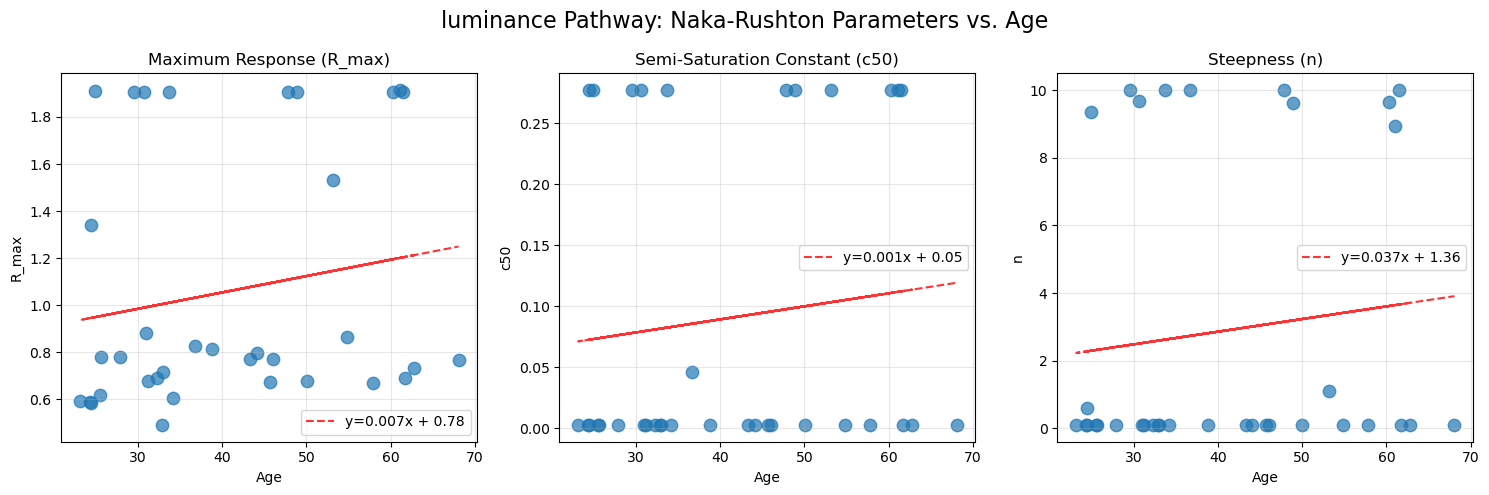

In [18]:
# ----------------------------------------------------------------------------------
# 10. Naka-Rushton Parameter Extraction & Age Correlation
# ----------------------------------------------------------------------------------

print("\n" + "="*60)
print("EXTRACTING NAKA-RUSHTON PARAMETERS")
print("="*60)

# List to store NR parameters for all subjects
nr_parameters = []

for subject in SUBJECTS:
    try:
        # 1. Load the subject's data
        X, y, times = load_subject_data(subject)
        
        # 2. Load the subject's decoding results to find their *individual* peak time
        ecoc_file = RESULTS_DIR / f"sub-{subject}_ecoc_results.npz"
        subject_data = np.load(ecoc_file)
        time_vec = subject_data['time_decoder']
        acc_vec = subject_data['accuracies']
        
        # Find peak within the defined time range
        in_range = (time_vec >= TIME_RANGE[0]) & (time_vec <= TIME_RANGE[1])
        peak_idx = np.argmax(acc_vec[in_range])
        peak_time = time_vec[in_range][peak_idx]
        
        print(f"Subject {subject}: Peak accuracy at {peak_time:.3f}s")

        # 3. Compute confusion matrix at this subject's peak time
        # (This reuses the `compute_confusion_matrices` function but for a specific time point)
        # We'll compute a single CM at the peak time instead of the whole range for efficiency
        n_trials, n_channels, n_times = X.shape
        n_windows = n_times - WINDOW_SIZE + 1
        window_times = times[WINDOW_SIZE//2:WINDOW_SIZE//2 + n_windows]
        
        # Find the time window closest to the peak
        target_window_idx = np.argmin(np.abs(window_times - peak_time))
        
        # Precompute window features for that specific window
        X_win = X[:, :, target_window_idx:target_window_idx+WINDOW_SIZE].mean(axis=2, keepdims=True)
        # X_win shape is now (n_trials, n_channels, 1)
        
        # Compute confusion matrix for this window using cross-validation
        cm_total = np.zeros((4, 4))
        for rep in range(N_REPEATS):
            cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=rep)
            for train_idx, test_idx in cv.split(X_win, y):
                X_train, X_test = X_win[train_idx], X_win[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                
                clf = OneVsRestClassifier(LinearDiscriminantAnalysis())
                clf.fit(X_train[:, :, 0], y_train) # Use the first (and only) dimension
                pred = clf.predict(X_test[:, :, 0])
                
                cm = confusion_matrix(y_test, pred, labels=[0, 1, 2, 3], normalize='true')
                cm_total += cm
        
        avg_cm = cm_total / (N_REPEATS * N_SPLITS)

        # 4. Compute MDS coordinates from the confusion matrix
        mds_coords, _ = compute_mds(avg_cm)
        
        # 5. Fit Naka-Rushton function to the contrast response (MDS coords vs. contrasts)
        contrasts = CONTRASTS[ANALYSIS_NAME]
        params = fit_naka_rushton(contrasts, mds_coords)
        
        if params is not None:
            R_max, c50, n = params
            print(f"  Fit successful: R_max={R_max:.2f}, c50={c50:.4f}, n={n:.2f}")
            
            # 6. Store the parameters along with subject info
            nr_parameters.append({
                'subject': subject,
                'age': AGE_DATA.get(subject),
                'peak_time': peak_time,
                'R_max': R_max,
                'c50': c50,
                'n': n
            })
        else:
            print(f"  Naka-Rushton fit failed for subject {subject}")

    except Exception as e:
        print(f"Error processing subject {subject} for NR analysis: {e}")
        continue

# Convert the results to a DataFrame
if nr_parameters:
    df_nr = pd.DataFrame(nr_parameters)
    
    # 7. Save the NR parameters to a CSV file
    nr_filename = f"{ANALYSIS_NAME}_naka_rushton_parameters.csv"
    df_nr.to_csv(RESULTS_DIR / nr_filename, index=False)
    print(f"\nNaka-Rushton parameters saved to: {RESULTS_DIR / nr_filename}")

    # 8. Plot NR parameters vs. Age
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{ANALYSIS_NAME} Pathway: Naka-Rushton Parameters vs. Age', fontsize=16)
    
    params_to_plot = ['R_max', 'c50', 'n']
    titles = ['Maximum Response (R_max)', 'Semi-Saturation Constant (c50)', 'Steepness (n)']
    
    for i, (param, title) in enumerate(zip(params_to_plot, titles)):
        # Check if the parameter was successfully fit for all subjects
        if param in df_nr.columns and not df_nr[param].isnull().all():
            axes[i].scatter(df_nr['age'], df_nr[param], s=80, alpha=0.7)
            axes[i].set_xlabel('Age')
            axes[i].set_ylabel(param)
            axes[i].set_title(title)
            
            # Add trendline
            z = np.polyfit(df_nr['age'], df_nr[param], 1)
            p = np.poly1d(z)
            axes[i].plot(df_nr['age'], p(df_nr['age']), "r--", alpha=0.8, 
                        label=f'y={z[0]:.3f}x + {z[1]:.2f}')
            axes[i].legend()
            axes[i].grid(alpha=0.3)
            
            # Calculate and print correlation
            corr = df_nr['age'].corr(df_nr[param])
            print(f"Correlation (Age vs. {param}): {corr:.3f}")
        else:
            axes[i].set_title(f"{title} (No Data)")
            
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{ANALYSIS_NAME}_nr_parameters_vs_age.png", dpi=150)
    plt.show()

else:
    print("No Naka-Rushton parameters were successfully extracted.")